<a href="https://colab.research.google.com/github/hanauert/Hausarbeit-GenAI/blob/main/07_stance_detection_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Data**

In [14]:
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt

In [15]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Plots**

In [16]:
paragraphs_merged_df = pd.read_csv('/content/drive/MyDrive/FKM/stance_detection/df_newspaper_filtered_by_paragraph_mergedAB.csv')

In [17]:
paragraphs_merged_df.head()

,metadata,body_text,title,date,month,newspaper,article_id,paragraph,lead,labels_NLI,scores_NLI
0,- Rembrandts Amsterdam. Goldene Zeiten? - Drib...,Im 17. Jahrhundert ist Amsterdam die Metropole...,- Rembrandts Amsterdam. Goldene Zeiten? - Drib...,2024-12-03,2024-12,FR,A_1,Die Ausstellung hinterfragt die traditionelle ...,Im 17. Jahrhundert ist Amsterdam die Metropole...,nicht negativ,0.999842
1,300 MODELLE IN 15 FARBEN - Wachsender Markt fü...,90 Prozent der Perücken sind aus „Premium-Synt...,300 MODELLE IN 15 FARBEN - Wachsender Markt fü...,2024-09-06,2024-09,FR,A_10,Die Büro- und Sozialräume im Gebäude sind mode...,90 Prozent der Perücken sind aus „Premium-Synt...,nicht negativ,0.999995
2,Abhängige von der Straße holen\n \nFrankfurter...,"VON STEVEN MICKSCH\nRäume zum Drogenkonsum, ni...",Abhängige von der Straße holen,2024-11-20,2024-11,FR,A_20,Noch eine Etage weiter oben soll es dann Notsc...,VON STEVEN MICKSCH,nicht negativ,0.993135
3,Alles German\n \nFrankfurter Rundschau\nDienst...,"In Hahndorf in Südaustralien, rund 30 Kilomete...",Alles German,2025-02-10,2025-02,FR,A_39,Im 19. Jahrhundert und bis weit ins 20. Jahrhu...,"In Hahndorf in Südaustralien, rund 30 Kilomete...",nicht negativ,0.999999
4,Alles für die Staatsräson\n \nFrankfurter Rund...,Die Berliner Ausländerbehörde bereitet die Abs...,Alles für die Staatsräson,2025-04-07,2025-04,FR,A_40,Vertreter:innen des Anwaltsteams sehen Paralle...,Die Berliner Ausländerbehörde bereitet die Abs...,nicht negativ,0.983100


##**Stance development over time**

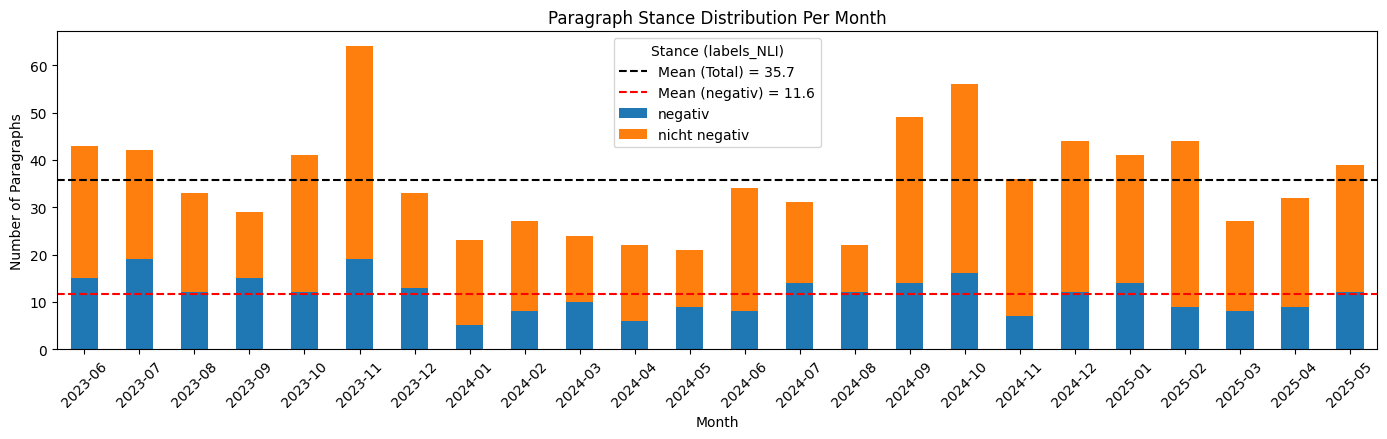

In [18]:
# Group by month and stance, then unstack to get stance categories as columns
stance_counts = paragraphs_merged_df.groupby(['month', 'labels_NLI']).size().unstack(fill_value=0)

# Filter to only include data up to and including May 2025
stance_counts = stance_counts[stance_counts.index <= '2025-05']

# Calculate total paragraphs per month (across all stances)
total_per_month = stance_counts.sum(axis=1)
mean_paragraphs = total_per_month.mean()

# Calculate mean of 'negativ' paragraphs per month
if 'negativ' in stance_counts.columns:
    mean_negativ = stance_counts['negativ'].mean()
else:
    mean_negativ = 0  # If 'negativ' doesn't exist, avoid error

# Plot the stacked bar chart
ax = stance_counts.plot(kind='bar', stacked=True, figsize=(14, 4.5))

# Add mean lines
plt.axhline(mean_paragraphs, color='black', linestyle='--', label=f'Mean (Total) = {mean_paragraphs:.1f}')
plt.axhline(mean_negativ, color='red', linestyle='--', label=f'Mean (negativ) = {mean_negativ:.1f}')

# Formatting
plt.title('Paragraph Stance Distribution Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Paragraphs')
plt.xticks(rotation=45)
plt.legend(title="Stance (labels_NLI)")
plt.tight_layout()
plt.show()

##**Abb.2: Stance development over time**

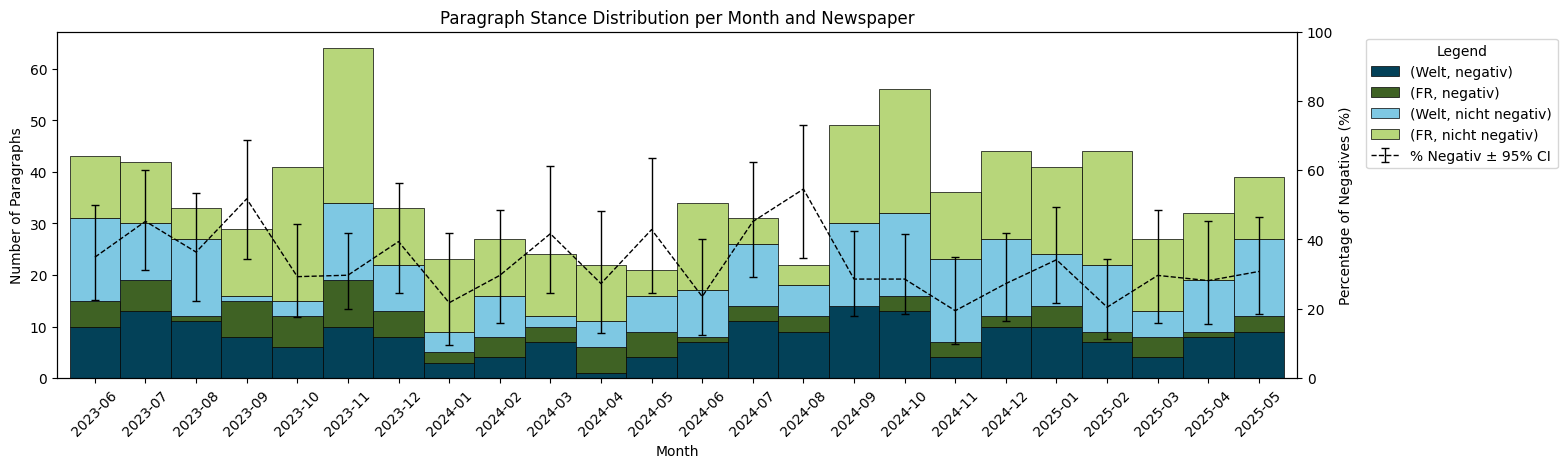

In [19]:
# Group and unstack as before
grouped = paragraphs_merged_df.groupby(['month', 'newspaper', 'labels_NLI']).size()
df_counts = grouped.unstack(level=['newspaper', 'labels_NLI'], fill_value=0)
df_counts = df_counts.sort_index()

# Define color map and stacking order as before
color_map = {
    ('Welt', 'negativ'): '#034158',       # dark blue
    ('FR', 'negativ'): '#3f6224',         # dark green
    ('Welt', 'nicht negativ'): '#7ec8e3', # light blue
    ('FR', 'nicht negativ'): '#b7d67a'    # light green
}

desired_order = [
    ('Welt', 'negativ'),
    ('FR', 'negativ'),
    ('Welt', 'nicht negativ'),
    ('FR', 'nicht negativ')
]

ordered_columns = [col for col in desired_order if col in df_counts.columns]
df_counts_ordered = df_counts[ordered_columns]

# Remove the last month
df_counts_ordered = df_counts_ordered.iloc[:-1]

colors = [color_map[col] for col in ordered_columns]

# Calculate total paragraphs per month
total_paragraphs = df_counts_ordered.sum(axis=1)

# Calculate total negative paragraphs per month (sum 'negativ' over newspapers)
neg_cols = [col for col in ordered_columns if col[1] == 'negativ']
total_negatives = df_counts_ordered[neg_cols].sum(axis=1)

from statsmodels.stats.proportion import proportion_confint

# Calculate raw percent negatives
percent_negatives = (total_negatives / total_paragraphs) * 100


# Compute Wilson confidence intervals
ci_low, ci_upp = proportion_confint(
    count=total_negatives,
    nobs=total_paragraphs,
    alpha=0.05,  # 95% confidence
    method='wilson'
)

# Convert to percentages
ci_low_pct = ci_low * 100
ci_upp_pct = ci_upp * 100


# Calculate percentage negative
percent_negatives = (total_negatives / total_paragraphs) * 100

# Plot stacked bars
fig, ax1 = plt.subplots(figsize=(16, 4.5))

df_counts_ordered.plot(
    kind='bar',
    stacked=True,
    color=colors,
    width=1,
    edgecolor='black',
    linewidth=0.5,
    ax=ax1
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Paragraphs')
ax1.set_title('Paragraph Stance Distribution per Month and Newspaper')

ax1.set_xticklabels(df_counts_ordered.index, rotation=45)

legend_labels = [f"{np} - {ln.capitalize()}" for np, ln in ordered_columns]
ax1.legend(legend_labels, title='Newspaper - Stance', bbox_to_anchor=(1.05, 1), loc='upper left')

# Create secondary y-axis for percentage line + CI
ax2 = ax1.twinx()
ax2.errorbar(
    percent_negatives.index,
    percent_negatives.values,
    yerr=[
        percent_negatives.values - ci_low_pct,
        ci_upp_pct - percent_negatives.values
    ],
    fmt='--',
    color='black',
    linewidth=1,
    capsize=3,
    label='% Negativ ± 95% CI'
)

ax2.set_ylabel('Percentage of Negatives (%)')
ax2.set_ylim(0, 100)

# After plotting both:

# Get handles and labels from bar plot legend
handles1, labels1 = ax1.get_legend_handles_labels()
# Get handles and labels from line plot legend
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them
ax1.legend(handles1 + handles2, labels1 + labels2, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

In [20]:
# Save the correct figure as PDF
fig.savefig("stance_distribution.pdf", format='pdf', bbox_inches='tight')

# Show plot
plt.show()

# Download from Colab
from google.colab import files
files.download("stance_distribution.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**Abb3: Stance distribution by newspapers**

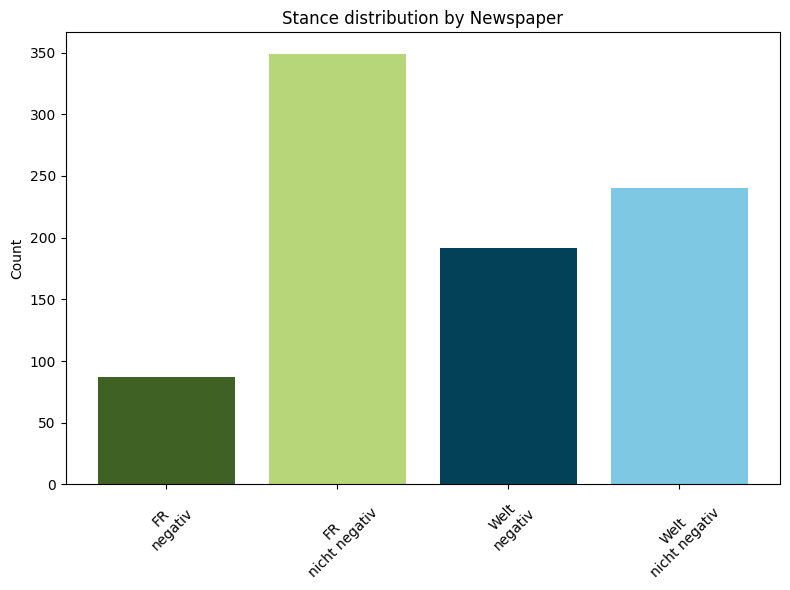

In [21]:
# Sample code assuming paragraphs_merged_df is already loaded

# Count occurrences for each newspaper and label
counts = paragraphs_merged_df.groupby(['newspaper', 'labels_NLI']).size().reset_index(name='count')

# Prepare plot
fig, ax = plt.subplots(figsize=(8,6))

# Plot each combination separately for custom coloring
for (newspaper, label), group_data in counts.groupby(['newspaper', 'labels_NLI']):
    ax.bar(f"{newspaper}\n{label}", group_data['count'].values[0],
           color=color_map[(newspaper, label)])

# Add labels and title
ax.set_ylabel('Count')
ax.set_title('Stance distribution by Newspaper')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Save the correct figure as PDF
fig.savefig("labels_by_newspaper.pdf", format='pdf', bbox_inches='tight')

# Show plot
plt.show()

# Download from Colab
from google.colab import files
files.download("labels_by_newspaper.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Filter rows where article_id starts with 'A_' or 'B_'
df_A = paragraphs_merged_df[paragraphs_merged_df['article_id'].str.startswith('A_')]
df_B = paragraphs_merged_df[paragraphs_merged_df['article_id'].str.startswith('B_')]

# Calculate percentage of 'negativ' in A
percent_negativ_A = (df_A['labels_NLI'] == 'negativ').mean() * 100

# Calculate percentage of 'negativ' in B
percent_negativ_B = (df_B['labels_NLI'] == 'negativ').mean() * 100

print(f"In group A, {percent_negativ_A:.1f}% are negativ.")
print(f"In group B, {percent_negativ_B:.1f}% are negativ.\n")


import pandas as pd

# Define groups A and B based on article_id prefix
paragraphs_merged_df['group'] = paragraphs_merged_df['article_id'].apply(lambda x: 'A' if x.startswith('A_') else ('B' if x.startswith('B_') else 'Other'))

# Filter only groups A and B (if you want)
df_filtered = paragraphs_merged_df[paragraphs_merged_df['group'].isin(['A', 'B'])]

# Group by 'group' and 'newspaper', then calculate % of 'negativ'
percent_negativ_grid = df_filtered.groupby(['group', 'newspaper'])['labels_NLI'].apply(
    lambda x: (x == 'negativ').mean() * 100
).unstack()

# Rename columns and index nicely (optional)
percent_negativ_grid.columns.name = 'Newspaper'
percent_negativ_grid.index.name = 'Group'

print(percent_negativ_grid)


In group A, 28.3% are negativ.
In group B, 36.7% are negativ.

Newspaper         FR       Welt
Group                          
A          17.557252  41.826923
B          23.563218  46.875000
